In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [4]:
print("\nDataset shape:", df.shape)


Dataset shape: (9551, 21)


In [5]:
required_columns = [
    "Latitude",
    "Longitude",
    "City",
    "Country Code",
    "Aggregate rating"
]

print(df[required_columns].info())

print("\nMissing values:")
print(df[required_columns].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Latitude          9551 non-null   float64
 1   Longitude         9551 non-null   float64
 2   City              9551 non-null   object 
 3   Country Code      9551 non-null   int64  
 4   Aggregate rating  9551 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 373.2+ KB
None

Missing values:
Latitude            0
Longitude           0
City                0
Country Code        0
Aggregate rating    0
dtype: int64


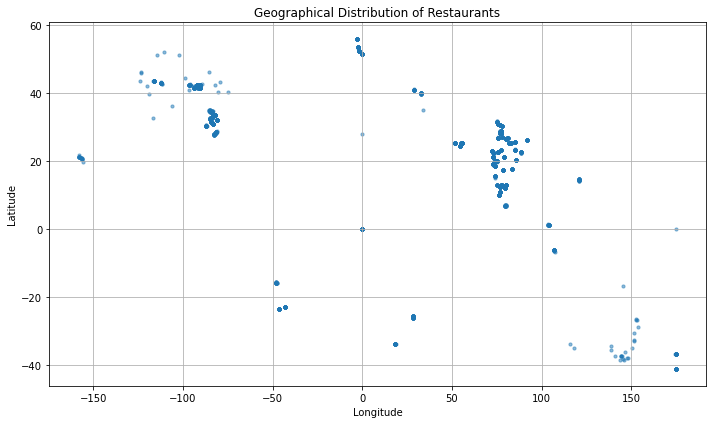

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.5,
    s=10
)

plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
city_distribution = df["City"].value_counts().head(10)

print("Top 10 cities by number of restaurants:")
print(city_distribution)

Top 10 cities by number of restaurants:
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: City, dtype: int64


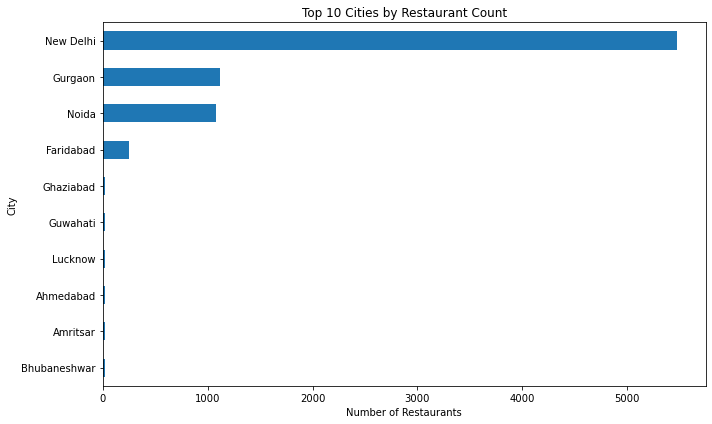

In [8]:
plt.figure(figsize=(10, 6))

city_distribution.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [9]:
city_rating = (
    df.groupby("City")["Aggregate rating"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

city_rating.head(10)

,count,mean
City,,
New Delhi,5473,2.438845
Gurgaon,1118,2.651431
Noida,1080,2.036204
Faridabad,251,1.866932
Ghaziabad,25,2.852000
Bhubaneshwar,21,3.980952
Lucknow,21,4.195238
Amritsar,21,3.685714
Ahmedabad,21,4.161905


In [10]:
city_rating_filtered = city_rating[city_rating["count"] >= 20]

city_rating_filtered.sort_values(
    "mean",
    ascending=False
).head(10)

,count,mean
City,,
London,20,4.535
Orlando,20,4.475
Rest of Hawaii,20,4.410
Tampa Bay,20,4.410
Bangalore,20,4.375
Dubai,20,4.370
Chennai,20,4.315
Ankara,20,4.305
Abu Dhabi,20,4.300


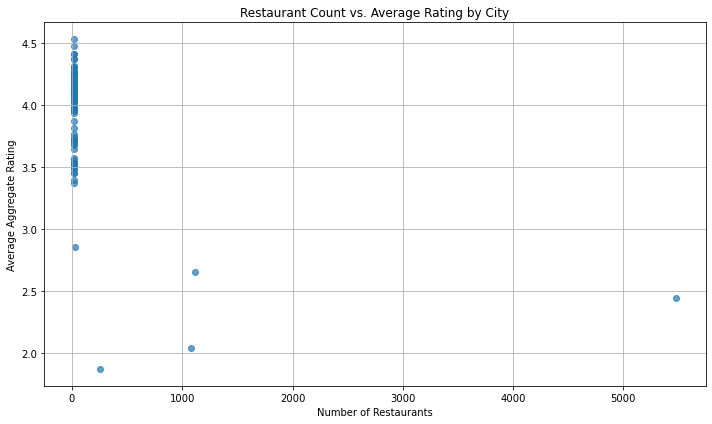

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    city_rating_filtered["count"],
    city_rating_filtered["mean"],
    alpha=0.7
)

plt.title("Restaurant Count vs. Average Rating by City")
plt.xlabel("Number of Restaurants")
plt.ylabel("Average Aggregate Rating")
plt.grid(True)
plt.tight_layout()

plt.show()


In [12]:
correlation = city_rating_filtered["count"].corr(
    city_rating_filtered["mean"]
)

print("Correlation between restaurant count and average rating:",
      round(correlation, 3))

Correlation between restaurant count and average rating: -0.475


## Findings and Interpretation

### 1. Geographical Distribution
The latitude and longitude coordinates were used to visualize the geographical distribution of restaurants. The map/scatter plot shows that restaurants are concentrated in specific geographic regions rather than being evenly distributed.

### 2. City-wise Distribution
The city-wise analysis shows that a small number of cities contain a large proportion of the restaurants in the dataset. The distribution is therefore concentrated around major restaurant markets.

### 3. Location and Rating
The average restaurant rating was compared with the number of restaurants across cities. The correlation coefficient was calculated to measure the strength of the relationship between restaurant concentration and average rating.

### 4. Overall Insight
The geographical analysis provides a better understanding of where restaurants are concentrated and how restaurant ratings vary across different locations.

## Conclusion

Task 3 provided a geographical view of the restaurant dataset using latitude and longitude coordinates. The analysis helped identify areas with a high concentration of restaurants and compare restaurant distribution across cities.

The relationship between restaurant concentration and average rating was also examined using city-level aggregation and correlation analysis. This demonstrates how geospatial information can be combined with other restaurant attributes to identify location-based patterns and insights.